In [2]:
from pyspark.sql import SparkSession

spark = SparkSession.builder.appName('Working with EDA').getOrCreate()
spark

**Create Dataset in Databricks**

In [4]:
from pyspark.sql.functions import col

appointments_data = [
 (1001, "Hyderabad", "Cardiology", "Apollo", 1500, "Completed"),
 (1002, "Bangalore", "Neurology", "Yashoda", 2200, "Completed"),
 (1003, "Mumbai", "Dermatology", "Care", 900, "Pending"),
 (1004, "Delhi", "Orthopedics", "Max", 2500, "Completed"),
 (1005, "Chennai", "Pediatrics", "Apollo", 1200, "Cancelled"),
 (1006, "Hyderabad", "Cardiology", "Care", 3000, "Completed"),
 (1007, "Bangalore", "Dermatology", "Apollo", 1000, "Completed"),
 (1008, "Mumbai", "Neurology", "Max", 2600, "Pending"),
 (1009, "Delhi", "Cardiology", "Yashoda", 2800, "Completed"),
 (1010, "Chennai", "Orthopedics", "Care", 2400, "Completed"),
 (1011, "Hyderabad", "Pediatrics", "Apollo", 1100, "Completed"),
 (1012, "Bangalore", "Cardiology", "Max", 3200, "Completed"),
 (1013, "Mumbai", "Pediatrics", "Yashoda", 1300, "Cancelled"),
 (1014, "Delhi", "Neurology", "Apollo", 2700, "Completed"),
 (1015, "Chennai", "Dermatology", "Care", 950, "Pending")
]

columns = [
    "appointment_id",
    "city",
    "department",
    "hospital",
    "consultation_fee",
    "status"
]

df = spark.createDataFrame(appointments_data, columns)

display(df.show())

+--------------+---------+-----------+--------+----------------+---------+
|appointment_id|     city| department|hospital|consultation_fee|   status|
+--------------+---------+-----------+--------+----------------+---------+
|          1001|Hyderabad| Cardiology|  Apollo|            1500|Completed|
|          1002|Bangalore|  Neurology| Yashoda|            2200|Completed|
|          1003|   Mumbai|Dermatology|    Care|             900|  Pending|
|          1004|    Delhi|Orthopedics|     Max|            2500|Completed|
|          1005|  Chennai| Pediatrics|  Apollo|            1200|Cancelled|
|          1006|Hyderabad| Cardiology|    Care|            3000|Completed|
|          1007|Bangalore|Dermatology|  Apollo|            1000|Completed|
|          1008|   Mumbai|  Neurology|     Max|            2600|  Pending|
|          1009|    Delhi| Cardiology| Yashoda|            2800|Completed|
|          1010|  Chennai|Orthopedics|    Care|            2400|Completed|
|          1011|Hyderabad

None

**Exercises**

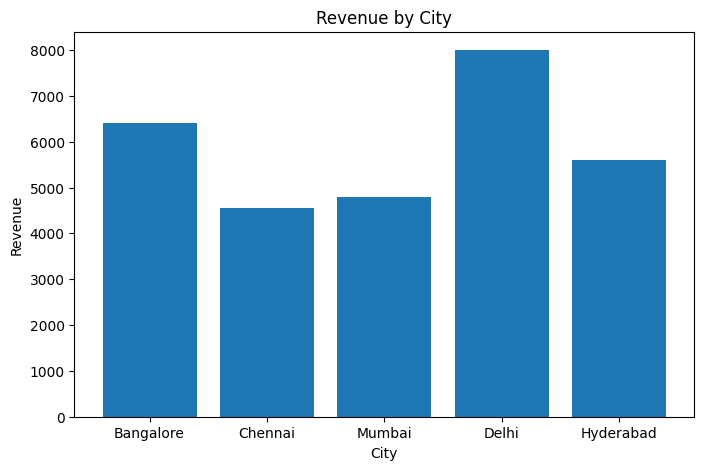

In [6]:
# Bar Chart: Revenue by City
import matplotlib.pyplot as plt

city_revenue = df.groupBy("city").sum("consultation_fee").toPandas()

plt.figure(figsize=(8,5))
plt.bar(city_revenue["city"], city_revenue["sum(consultation_fee)"])
plt.title("Revenue by City")
plt.xlabel("City")
plt.ylabel("Revenue")
plt.show()

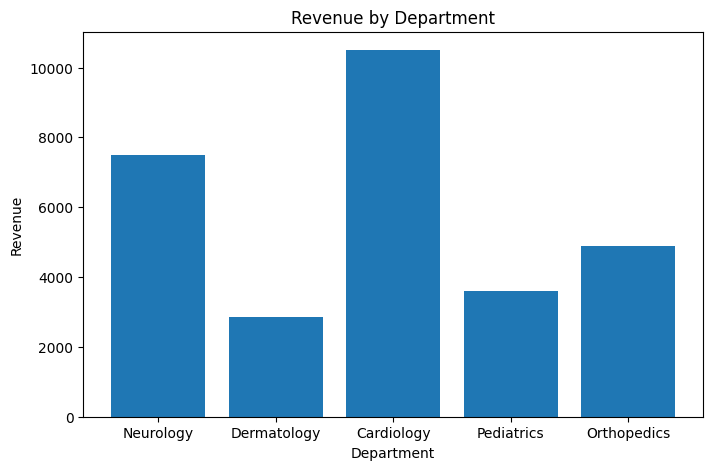

In [7]:
# Bar Chart: Revenue by Department
dept_revenue = df.groupBy("department").sum("consultation_fee").toPandas()

plt.figure(figsize=(8,5))
plt.bar(dept_revenue["department"], dept_revenue["sum(consultation_fee)"])
plt.title("Revenue by Department")
plt.xlabel("Department")
plt.ylabel("Revenue")
plt.show()

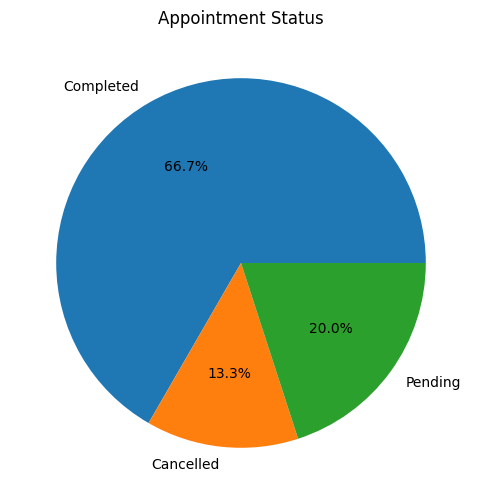

In [8]:
# Pie Chart: Appointment Status
status = df.groupBy("status").count().toPandas()

plt.figure(figsize=(6,6))
plt.pie(status["count"],labels=status["status"],autopct="%1.1f%%")
plt.title("Appointment Status")
plt.show()

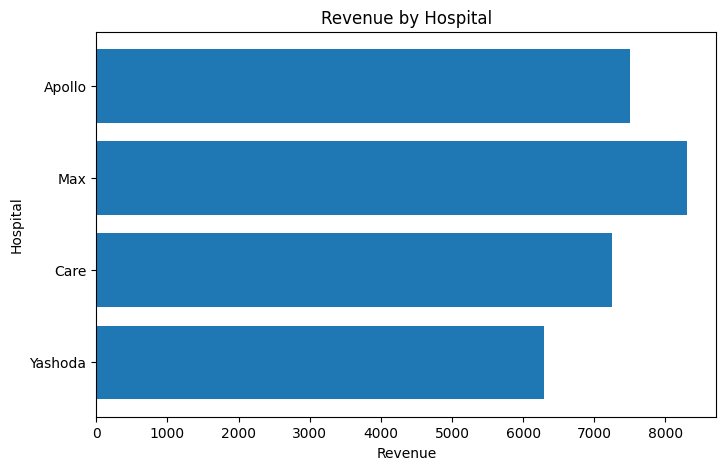

In [9]:
# Horizontal Bar: Revenue by Hospital
hospital = df.groupBy("hospital").sum("consultation_fee").toPandas()

plt.figure(figsize=(8,5))
plt.barh(hospital["hospital"],hospital["sum(consultation_fee)"])
plt.title("Revenue by Hospital")
plt.xlabel("Revenue")
plt.ylabel("Hospital")
plt.show()

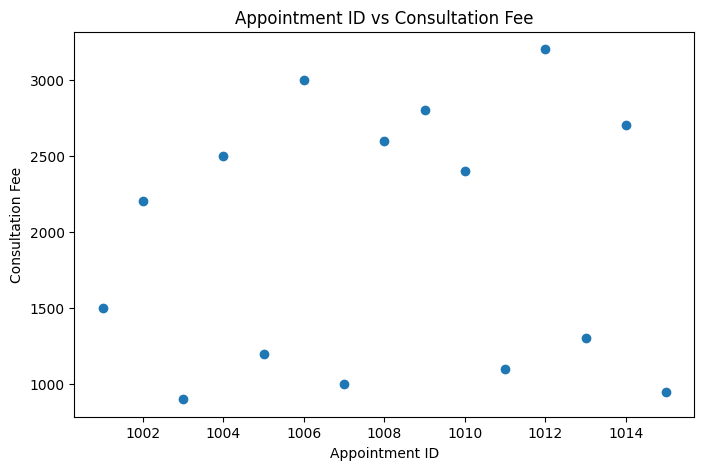

In [10]:
# Scatter Plot: Appointment ID vs Fee
scatter = df.toPandas()

plt.figure(figsize=(8,5))
plt.scatter(scatter["appointment_id"],scatter["consultation_fee"])
plt.title("Appointment ID vs Consultation Fee")
plt.xlabel("Appointment ID")
plt.ylabel("Consultation Fee")
plt.show()

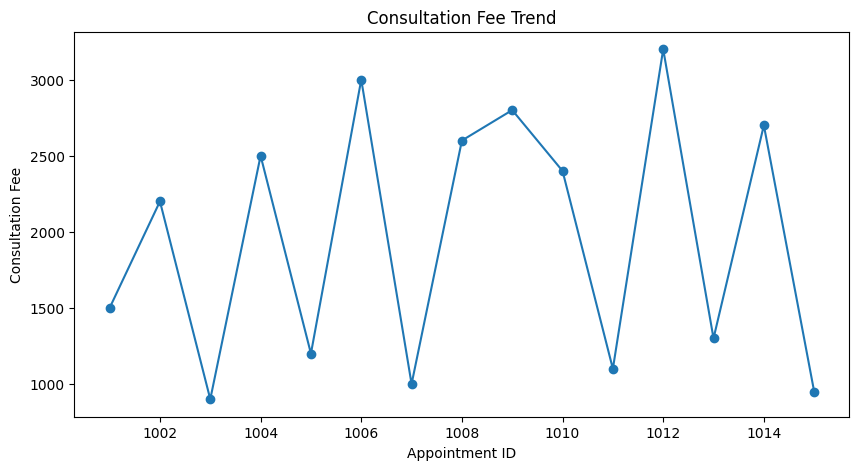

In [11]:
# Line Chart: Fee Trend by Appointment
line = df.orderBy("appointment_id").toPandas()

plt.figure(figsize=(10,5))
plt.plot(line["appointment_id"],line["consultation_fee"],marker="o")
plt.title("Consultation Fee Trend")
plt.xlabel("Appointment ID")
plt.ylabel("Consultation Fee")
plt.show()

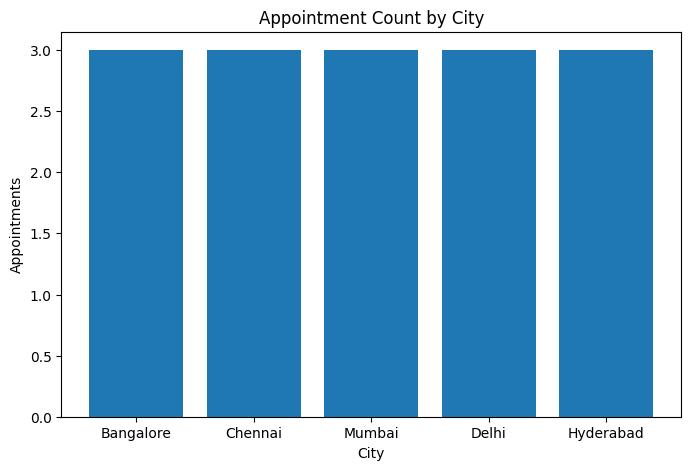

In [12]:
# 1
city = df.groupBy("city").count().toPandas()

plt.figure(figsize=(8,5))
plt.bar(city["city"], city["count"])
plt.title("Appointment Count by City")
plt.xlabel("City")
plt.ylabel("Appointments")
plt.show()

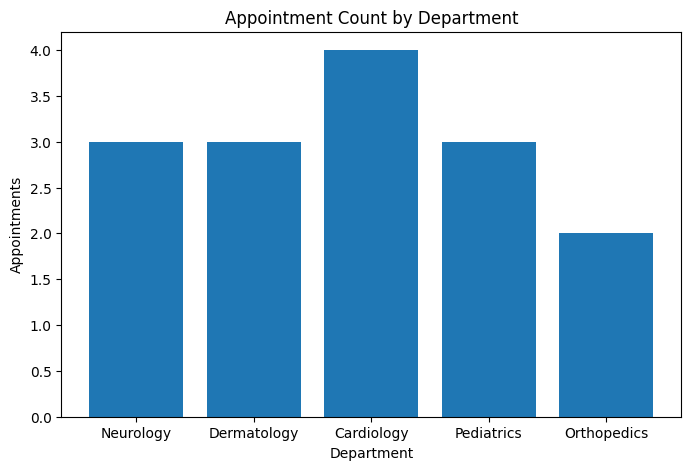

In [13]:
# 2
department = df.groupBy("department").count().toPandas()

plt.figure(figsize=(8,5))
plt.bar(department["department"], department["count"])
plt.title("Appointment Count by Department")
plt.xlabel("Department")
plt.ylabel("Appointments")
plt.show()

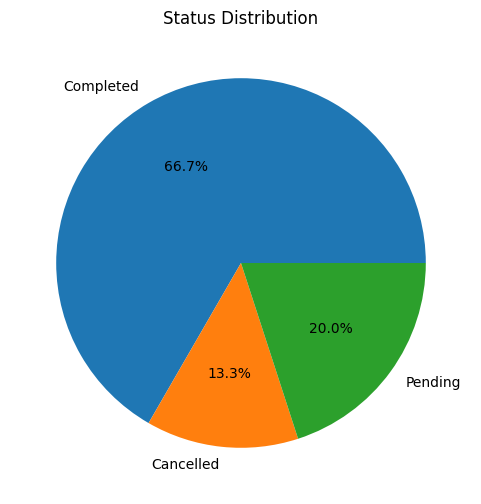

In [14]:
# 3
status = df.groupBy("status").count().toPandas()

plt.figure(figsize=(6,6))
plt.pie(status["count"],labels=status["status"],autopct="%1.1f%%")
plt.title("Status Distribution")
plt.show()

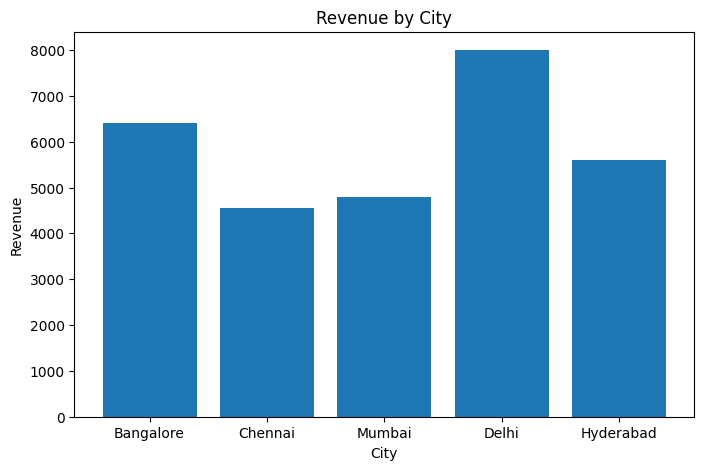

In [15]:
# 4
city_revenue = df.groupBy("city").sum("consultation_fee").toPandas()

plt.figure(figsize=(8,5))
plt.bar(city_revenue["city"],city_revenue["sum(consultation_fee)"])
plt.title("Revenue by City")
plt.xlabel("City")
plt.ylabel("Revenue")
plt.show()

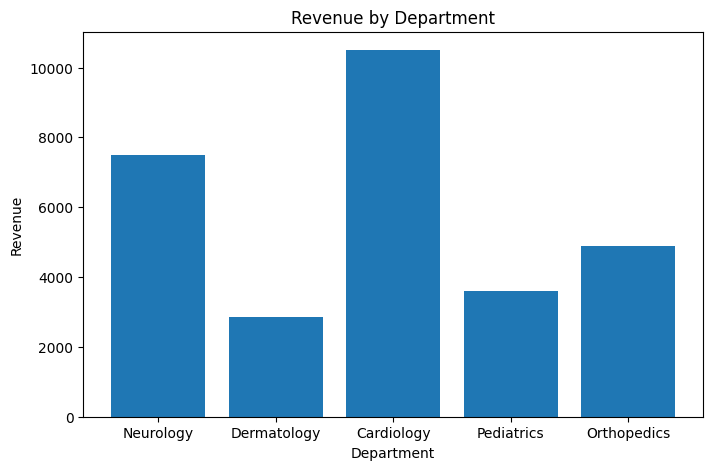

In [16]:
# 5
dept_revenue = df.groupBy("department").sum("consultation_fee").toPandas()

plt.figure(figsize=(8,5))
plt.bar(dept_revenue["department"],dept_revenue["sum(consultation_fee)"])
plt.title("Revenue by Department")
plt.xlabel("Department")
plt.ylabel("Revenue")
plt.show()

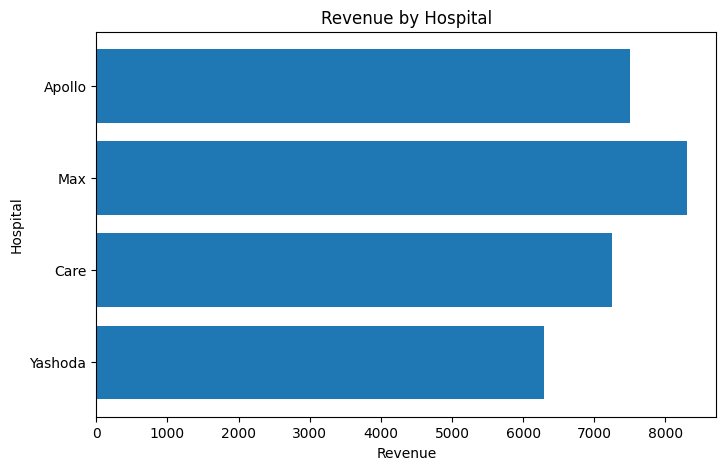

In [17]:
# 6
hospital = df.groupBy("hospital").sum("consultation_fee").toPandas()

plt.figure(figsize=(8,5))
plt.barh(hospital["hospital"],hospital["sum(consultation_fee)"])
plt.title("Revenue by Hospital")
plt.xlabel("Revenue")
plt.ylabel("Hospital")
plt.show()

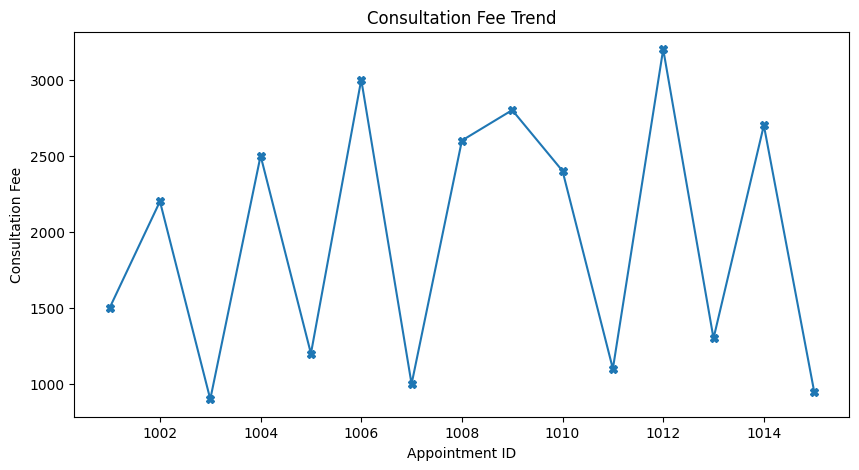

In [19]:
# 7
line = df.orderBy("appointment_id").toPandas()

plt.figure(figsize=(10,5))
plt.plot(line["appointment_id"],line["consultation_fee"],marker="X")
plt.title("Consultation Fee Trend")
plt.xlabel("Appointment ID")
plt.ylabel("Consultation Fee")
plt.show()

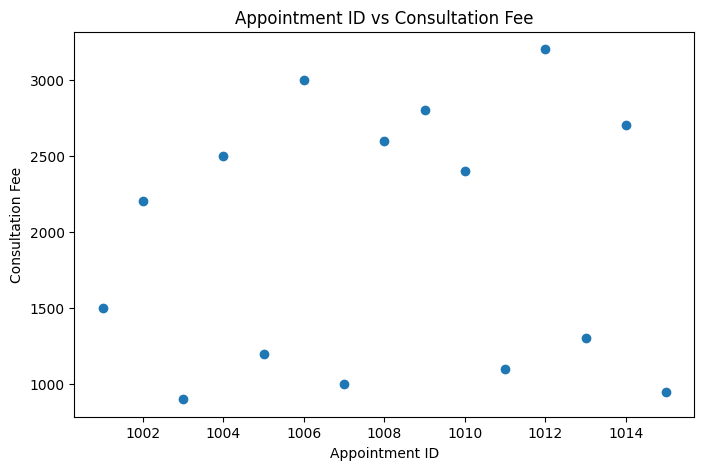

In [20]:
# 8
scatter = df.toPandas()

plt.figure(figsize=(8,5))
plt.scatter(scatter["appointment_id"], scatter["consultation_fee"])
plt.title("Appointment ID vs Consultation Fee")
plt.xlabel("Appointment ID")
plt.ylabel("Consultation Fee")
plt.show()

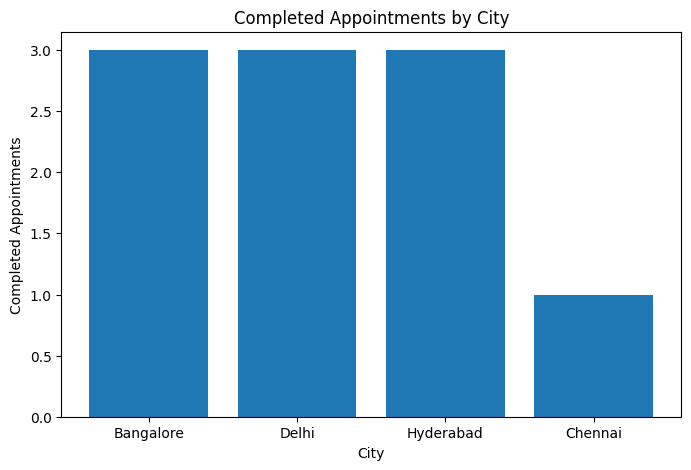

In [24]:
# 9
completed = df.filter(col("status") == "Completed")
city_completed = completed.groupBy("city").count().toPandas()

plt.figure(figsize=(8,5))
plt.bar(city_completed["city"], city_completed["count"])
plt.title("Completed Appointments by City")
plt.xlabel("City")
plt.ylabel("Completed Appointments")
plt.show()

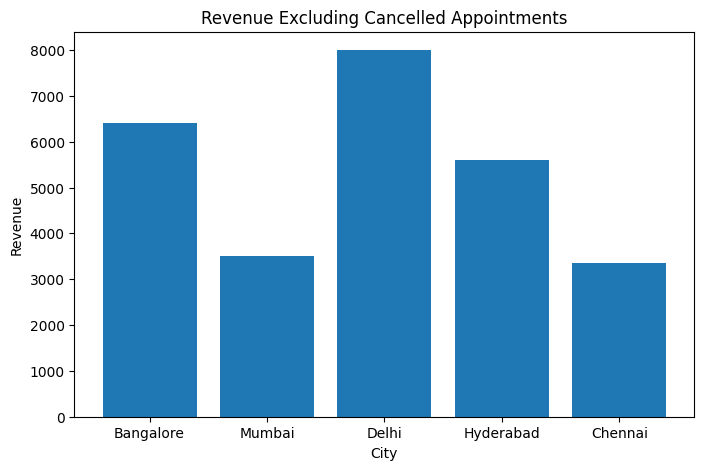

In [25]:
# 10
revenue = df.filter(col("status") != "Cancelled")

city_revenue = revenue.groupBy("city").sum("consultation_fee").toPandas()

plt.figure(figsize=(8,5))
plt.bar(city_revenue["city"], city_revenue["sum(consultation_fee)"])
plt.title("Revenue Excluding Cancelled Appointments")
plt.xlabel("City")
plt.ylabel("Revenue")
plt.show()

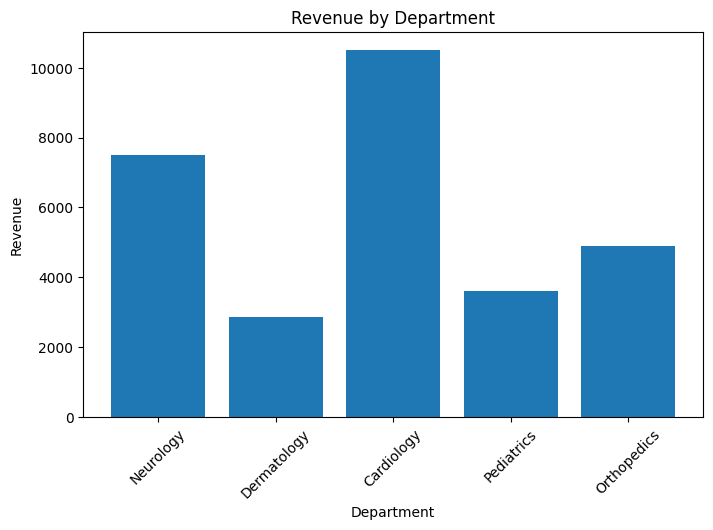

In [27]:
# 11
dept_revenue = df.groupBy("department").sum("consultation_fee").toPandas()

plt.figure(figsize=(8,5))
plt.bar(dept_revenue["department"],dept_revenue["sum(consultation_fee)"])
plt.title("Revenue by Department")
plt.xlabel("Department")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

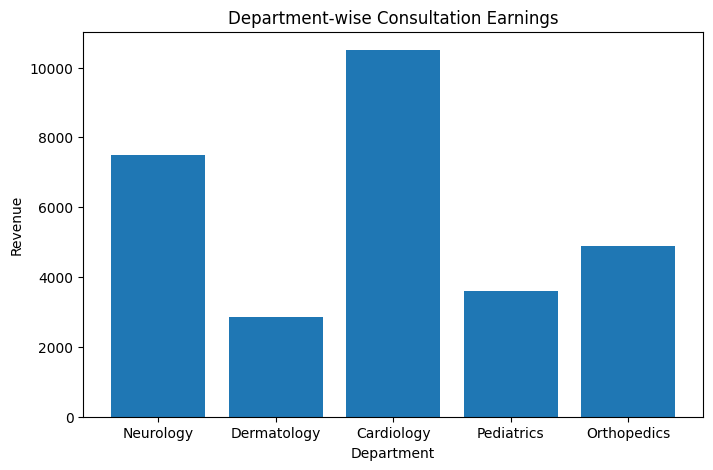

In [28]:
# 12
dept_revenue = df.groupBy("department").sum("consultation_fee").toPandas()

plt.figure(figsize=(8,5))
plt.bar(dept_revenue["department"],dept_revenue["sum(consultation_fee)"])
plt.title("Department-wise Consultation Earnings")
plt.xlabel("Department")
plt.ylabel("Revenue")
plt.show()

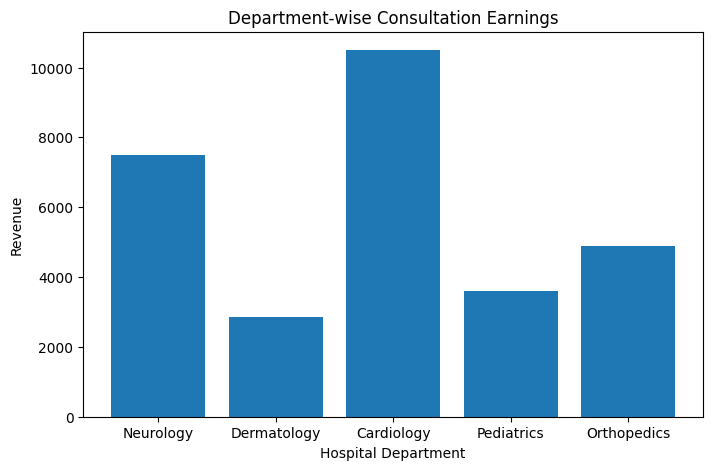

In [29]:
# 13
dept_revenue = df.groupBy("department").sum("consultation_fee").toPandas()

plt.figure(figsize=(8,5))
plt.bar(dept_revenue["department"],dept_revenue["sum(consultation_fee)"])
plt.title("Department-wise Consultation Earnings")
plt.xlabel("Hospital Department")
plt.ylabel("Revenue")
plt.show()

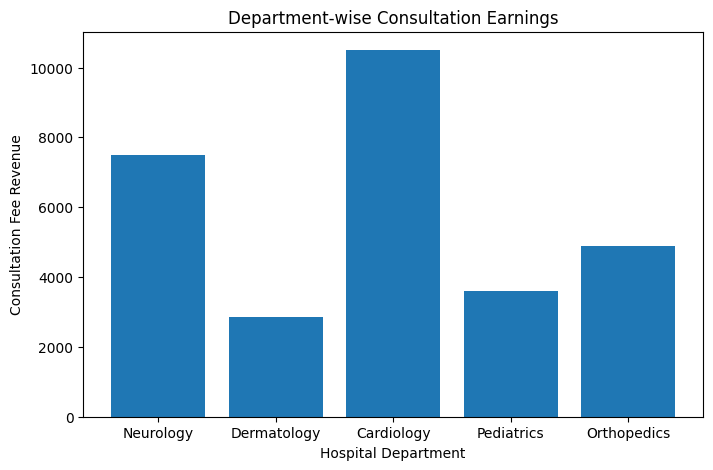

In [30]:
# 14
dept_revenue = df.groupBy("department").sum("consultation_fee").toPandas()

plt.figure(figsize=(8,5))
plt.bar(dept_revenue["department"],dept_revenue["sum(consultation_fee)"])
plt.title("Department-wise Consultation Earnings")
plt.xlabel("Hospital Department")
plt.ylabel("Consultation Fee Revenue")
plt.show()

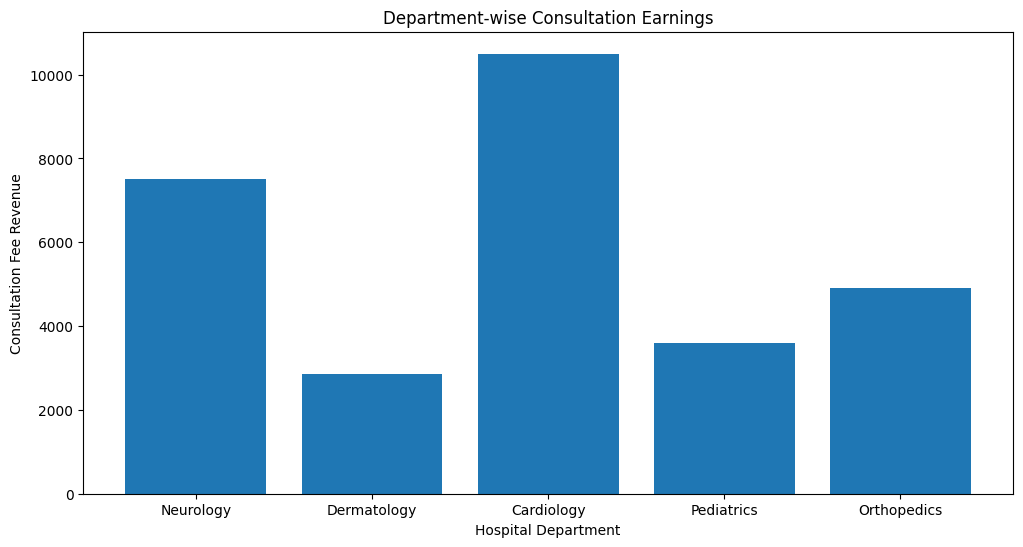

In [34]:
# 15
dept_revenue = df.groupBy("department").sum("consultation_fee").toPandas()

plt.figure(figsize=(12,6))
plt.bar(dept_revenue["department"],dept_revenue["sum(consultation_fee)"])
plt.title("Department-wise Consultation Earnings")
plt.xlabel("Hospital Department")
plt.ylabel("Consultation Fee Revenue")
plt.show()

In [39]:
# 16
from pyspark.sql.functions import *

top_city = df.groupBy("city").agg(sum("consultation_fee").alias("revenue")).orderBy(col("revenue").desc()).limit(3)
display(top_city.show())

+---------+-------+
|     city|revenue|
+---------+-------+
|    Delhi|   8000|
|Bangalore|   6400|
|Hyderabad|   5600|
+---------+-------+



None

In [40]:
# 17
top_department = df.groupBy("department").agg(sum("consultation_fee").alias("revenue")).orderBy(col("revenue").desc()).limit(3)
display(top_department.show())

+-----------+-------+
| department|revenue|
+-----------+-------+
| Cardiology|  10500|
|  Neurology|   7500|
|Orthopedics|   4900|
+-----------+-------+



None

In [44]:
# 18
lowest_hospital = df.groupBy("hospital").agg(sum("consultation_fee").alias("revenue")).orderBy(col("revenue")).limit(1)
display(lowest_hospital.show())

+--------+-------+
|hospital|revenue|
+--------+-------+
| Yashoda|   6300|
+--------+-------+



None

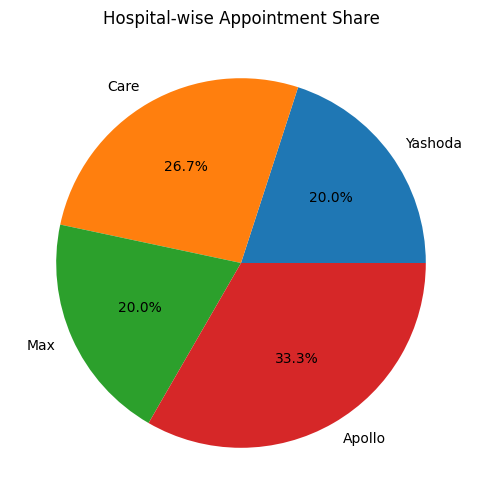

In [45]:
# 19
hospital = df.groupBy("hospital").count().toPandas()

plt.figure(figsize=(6,6))
plt.pie(hospital["count"],labels=hospital["hospital"],autopct="%1.1f%%")
plt.title("Hospital-wise Appointment Share")
plt.show()

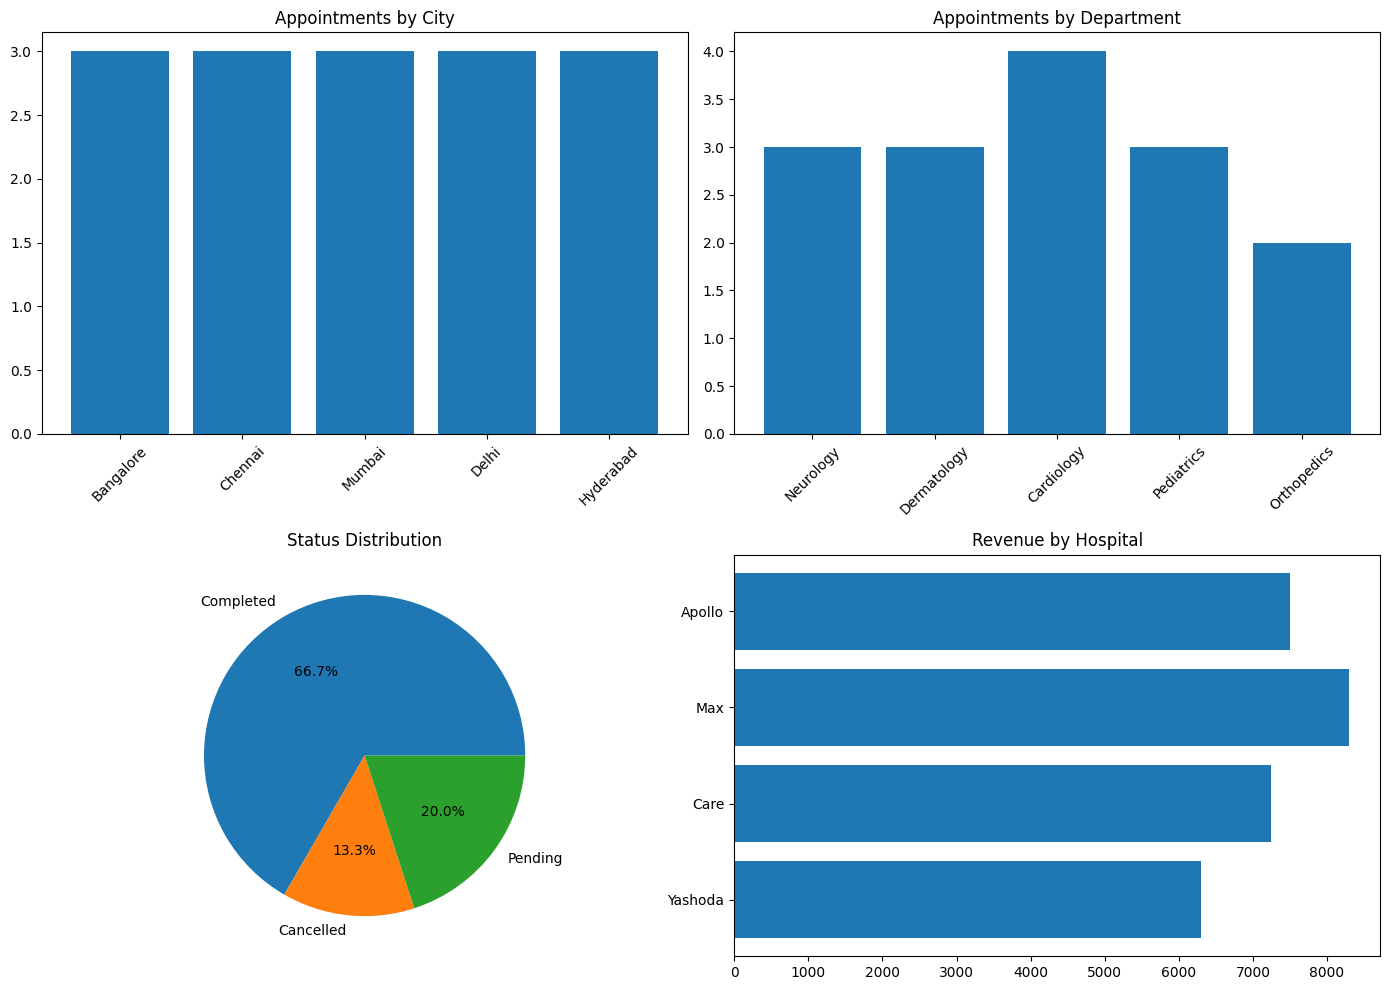

In [46]:
# 20
import matplotlib.pyplot as plt

fig, ax = plt.subplots(2,2,figsize=(14,10))

city = df.groupBy("city").count().toPandas()
ax[0,0].bar(city["city"], city["count"])
ax[0,0].set_title("Appointments by City")
ax[0,0].tick_params(axis="x", rotation=45)

department = df.groupBy("department").count().toPandas()
ax[0,1].bar(department["department"], department["count"])
ax[0,1].set_title("Appointments by Department")
ax[0,1].tick_params(axis="x", rotation=45)

status = df.groupBy("status").count().toPandas()
ax[1,0].pie(status["count"], labels=status["status"], autopct="%1.1f%%")
ax[1,0].set_title("Status Distribution")

hospital = df.groupBy("hospital").sum("consultation_fee").toPandas()
ax[1,1].barh(hospital["hospital"], hospital["sum(consultation_fee)"])
ax[1,1].set_title("Revenue by Hospital")

plt.tight_layout()
plt.show()